In [1]:
# https://dc.ewu.edu/data_sets/3/?utm_source=gemini

import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
import numpy as np
import pandas as pd
import seaborn as sns
#import mlba
#%matplotlib inline

In [2]:
# Load TSV Data (File has no headers)
# Columns: [Company, Sector_Code, Position_Code, Year, Person]
df = pd.read_csv("interlocking.tsv", sep="\t", header=None)
df.columns = ["company", "sector_code", "position_code", "year", "person"]
df.head(20)

,company,sector_code,position_code,year,person
0,U.S. STEEL,1,0,1969,"WALKER,W.A."
1,U.S. STEEL,1,0,1969,"TYSON,R.C."
2,U.S. STEEL,1,0,1969,"TENNANT,J.S."
3,U.S. STEEL,1,0,1969,"SPEER,E.B."
4,U.S. STEEL,1,0,1969,"RAWLINS,B.L."
5,U.S. STEEL,1,0,1969,"LARRY,R.H."
6,U.S. STEEL,1,0,1969,"HYDE,R.W."
7,U.S. STEEL,1,0,1969,"GOTT,E.H."
8,U.S. STEEL,1,2,1969,"WORTHINGTON,L.B."
9,U.S. STEEL,1,2,1969,"WINGATE,H.S."


In [3]:

# Clean duplicate seat roles to get unique company-person edges
#   same person could hold multiple positions (e.g. director or other officer)
df_unique = df[["company", "person"]].drop_duplicates()
df_clean = df_unique

print(f"Dataset Summary:")
print(f" - Companies: {df_unique['company'].nunique()}")
print(f" - Directors: {df_unique['person'].nunique()}")
print(f" - Board Seats: {len(df_unique)}")


Dataset Summary:
 - Companies: 167
 - Directors: 2932
 - Board Seats: 3507


In [4]:
# Calculate board seat counts
director_counts = df_clean["person"].value_counts()

# Build frequency table DataFrame
summary_df = (
    director_counts.value_counts()
    .sort_index()
    .reset_index(name="Number of Directors")
)
summary_df.columns = ["Board Seats Held", "Number of Directors"]

total_directors = summary_df["Number of Directors"].sum()
summary_df["Percentage"] = (
    summary_df["Number of Directors"] / total_directors * 100
).map("{:.2f}%".format)
summary_df["Cumulative Percentage"] = (
    (summary_df["Number of Directors"].cumsum() / total_directors) * 100
).map("{:.2f}%".format)

print(summary_df.to_string(index=False))

 Board Seats Held  Number of Directors Percentage Cumulative Percentage
                1                 2527     86.19%                86.19%
                2                  280      9.55%                95.74%
                3                   90      3.07%                98.81%
                4                   28      0.95%                99.76%
                5                    5      0.17%                99.93%
                6                    1      0.03%                99.97%
                7                    1      0.03%               100.00%


- giant component 153 out of 167 companies (91.6%) are linked together in a single, continuous network through shared directors.
-Money-center banks and life insurance giants served as the primary hubs connecting disparate industrial sectors:
    First National City Bank (NYC) [now Citigroup]: 38 company interlocks
- Mellon National Bank & Trust and Gulf Oil shared 5 directors.

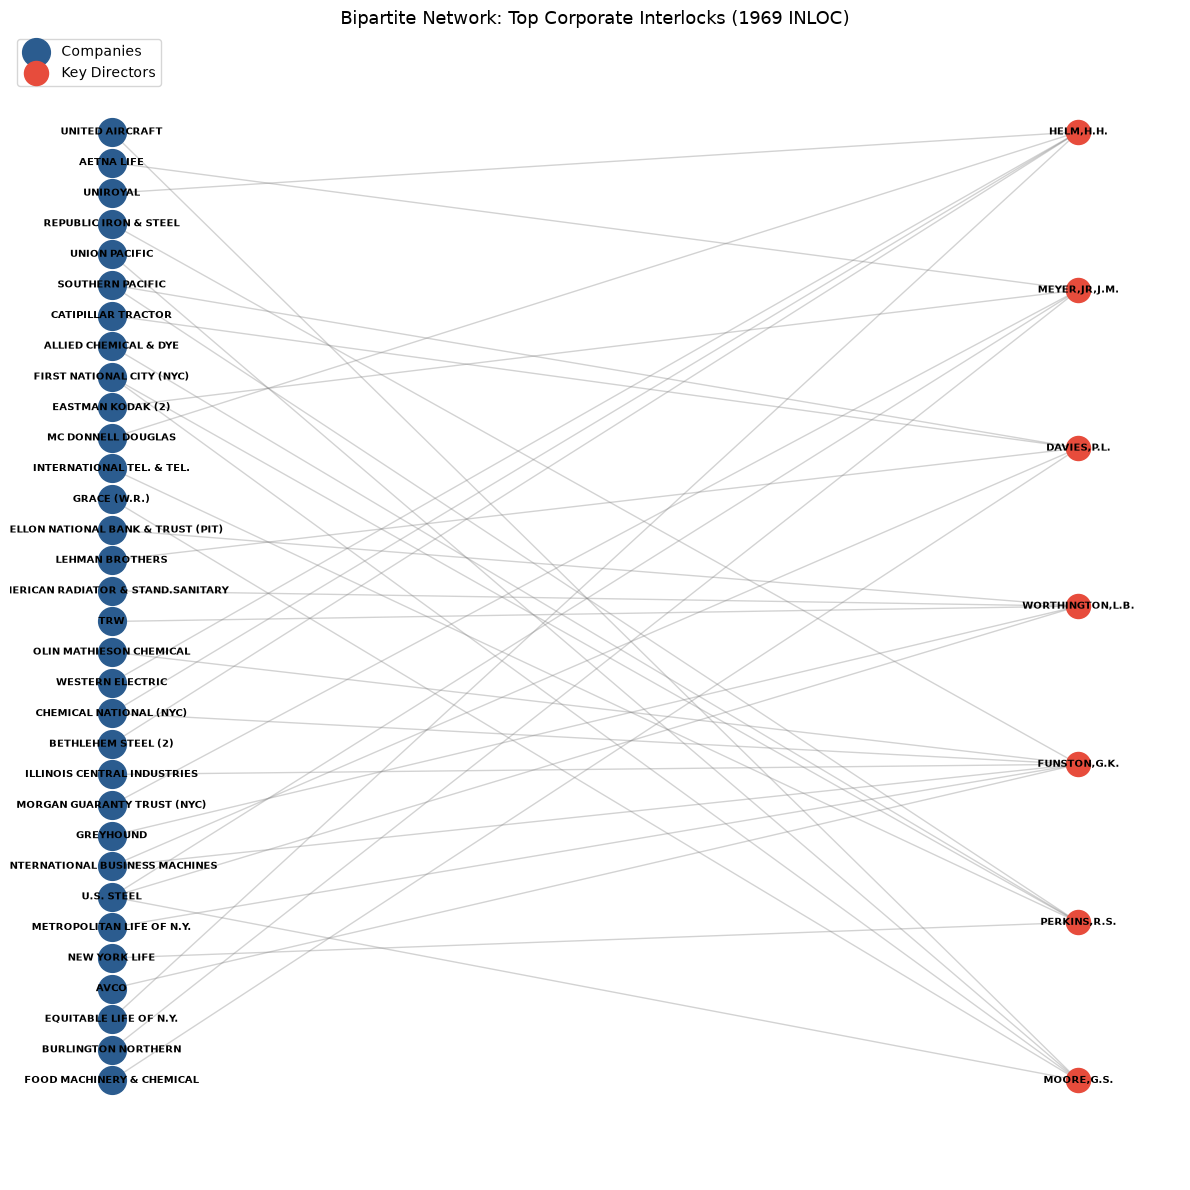

In [5]:
top_directors = director_counts[director_counts >= 5].index.tolist()
sub_df = df_clean[df_clean["person"].isin(top_directors)]

companies = set(sub_df["company"])
people = set(sub_df["person"])

# 3. Create Bipartite Graph
B = nx.Graph()
# Expressly set the bipartite attribute (0 for companies, 1 for directors)
B.add_nodes_from(companies, bipartite=0)
B.add_nodes_from(people, bipartite=1)
B.add_edges_from(zip(sub_df["company"], sub_df["person"]))

# 4. Generate Bipartite Layout (Companies on left, Directors on right)
pos = nx.bipartite_layout(B, companies)

# 5. Draw Graph
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=companies,
    node_color="#2b5c8f",
    node_size=400,
    label="Companies",
)
nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=people,
    node_color="#e74c3c",
    node_size=300,
    label="Key Directors",
)

nx.draw_networkx_edges(B, pos, alpha=0.35, edge_color="gray")
nx.draw_networkx_labels(B, pos, font_size=7, font_weight="bold")

plt.title(
    "Bipartite Network: Top Corporate Interlocks (1969 INLOC)", fontsize=13
)
plt.legend(scatterpoints=1, loc="upper left")
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# 2. Construct Full Bipartite Graph
companies = set(df_clean["company"])
people = set(df_clean["person"])

B = nx.Graph()
B.add_nodes_from(companies, bipartite=0)
B.add_nodes_from(people, bipartite=1)
B.add_edges_from(zip(df_clean["company"], df_clean["person"]))

# 3. Separate Bipartite Sets
companies_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}
people_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == 1}

# 4. Display Core Metrics
print("=== Bipartite Network Summary ===")
print(f"Total Nodes: {B.number_of_nodes()}")
print(f"  - Company Nodes: {len(companies_nodes)}")
print(f"  - Person Nodes:  {len(people_nodes)}")
print(f"Total Edges:       {B.number_of_edges()}")

# 5. Extract Highest Degree Companies
top_companies = sorted(
    [(n, B.degree(n)) for n in companies_nodes],
    key=lambda x: x[1],
    reverse=True,
)[:10]

print("\nTop 10 Companies by Board Size:")
for comp, deg in top_companies:
    print(f"  {comp:35s}: {deg}")

# 6. Extract Highest Degree People
top_people = sorted(
    [(n, B.degree(n)) for n in people_nodes], key=lambda x: x[1], reverse=True
)[:10]

print("\nTop 10 People by Board Seats:")
for person, deg in top_people:
    print(f"  {person:25s}: {deg}")

=== Bipartite Network Summary ===
Total Nodes: 3099
  - Company Nodes: 167
  - Person Nodes:  2932
Total Edges:       3507

Top 10 Companies by Board Size:
  PAINE WEBBER INC.                  : 86
  EASTMAN DILLON UNION SECURTIES     : 64
  LOEB, RHOADES & CO.                : 45
  FIRST NATIONAL CITY (NYC)          : 44
  LEHMAN BROTHERS                    : 39
  EQUITABLE LIFE OF N.Y.             : 37
  NORTHWESTERN MUTUAL LIFE           : 36
  SEABOARD AIR LINE                  : 30
  HAYDEN, STONE & CO.                : 30
  GRACE (W.R.)                       : 29

Top 10 People by Board Seats:
  FUNSTON,G.K.             : 7
  HELM,H.H.                : 6
  DAVIES,P.L.              : 5
  MEYER,JR,J.M.            : 5
  WORTHINGTON,L.B.         : 5
  PERKINS,R.S.             : 5
  MOORE,G.S.               : 5
  GATES,T.S.               : 4
  MUDD,H.T.                : 4
  MORTIMER,C.G.            : 4


In [7]:
# 2. Project onto Company nodes
# Pass the bipartite graph 'B' and the set of nodes you want to project onto ('companies')
company_graph = bipartite.weighted_projected_graph(B, companies)

print("Projected Company Network Summary:")
print(f"  Nodes (Companies):  {company_graph.number_of_nodes()}")
print(f"  Edges (Interlocks): {company_graph.number_of_edges()}")

# 3. Inspect top company pairs sharing multiple directors
top_pairs = sorted(
    company_graph.edges(data=True), key=lambda x: x[2]["weight"], reverse=True
)[:5]

print("\nTop Interlocked Pairs:")
for u, v, data in top_pairs:
    print(f"  {u} <---> {v}: {data['weight']} shared directors")

Projected Company Network Summary:
  Nodes (Companies):  167
  Edges (Interlocks): 647

Top Interlocked Pairs:
  SEABOARD AIR LINE <---> LOUISVILLE & NASHVILLE: 5 shared directors
  MELLON NATIONAL BANK & TRUST (PIT) <---> GULF OIL: 5 shared directors
  AVCO <---> REPUBLIC IRON & STEEL: 4 shared directors
  NATIONAL CASH REGISTER <---> FIRST NATIONAL CITY (NYC): 4 shared directors
  INTERNATIONAL HARVESTER <---> CONTINENTAL ILLINOIS NATIONAL (CHI): 4 shared directors


                                 Degree  Weighted_Degree  Betweenness  \
FIRST NATIONAL CITY (NYC)            38               62     0.075496   
CHASE MANHATTAN (NYC)                25               31     0.069606   
METROPOLITAN LIFE OF N.Y.            26               31     0.061419   
CHEMICAL NATIONAL (NYC)              28               38     0.053028   
MORGAN GUARANTY TRUST (NYC)          27               34     0.046312   
EQUITABLE LIFE OF N.Y.               24               31     0.044856   
INTERNATIONAL BUSINESS MACHINES      24               29     0.043014   
SOUTHERN PACIFIC                     19               23     0.037406   
PENN CENTRAL                         13               14     0.035534   
KENNECOTT COPPER                     14               16     0.035450   

                                 Closeness  Eigenvector  
FIRST NATIONAL CITY (NYC)         0.483266     0.386371  
CHASE MANHATTAN (NYC)             0.426935     0.165079  
METROPOLITAN LIFE OF N

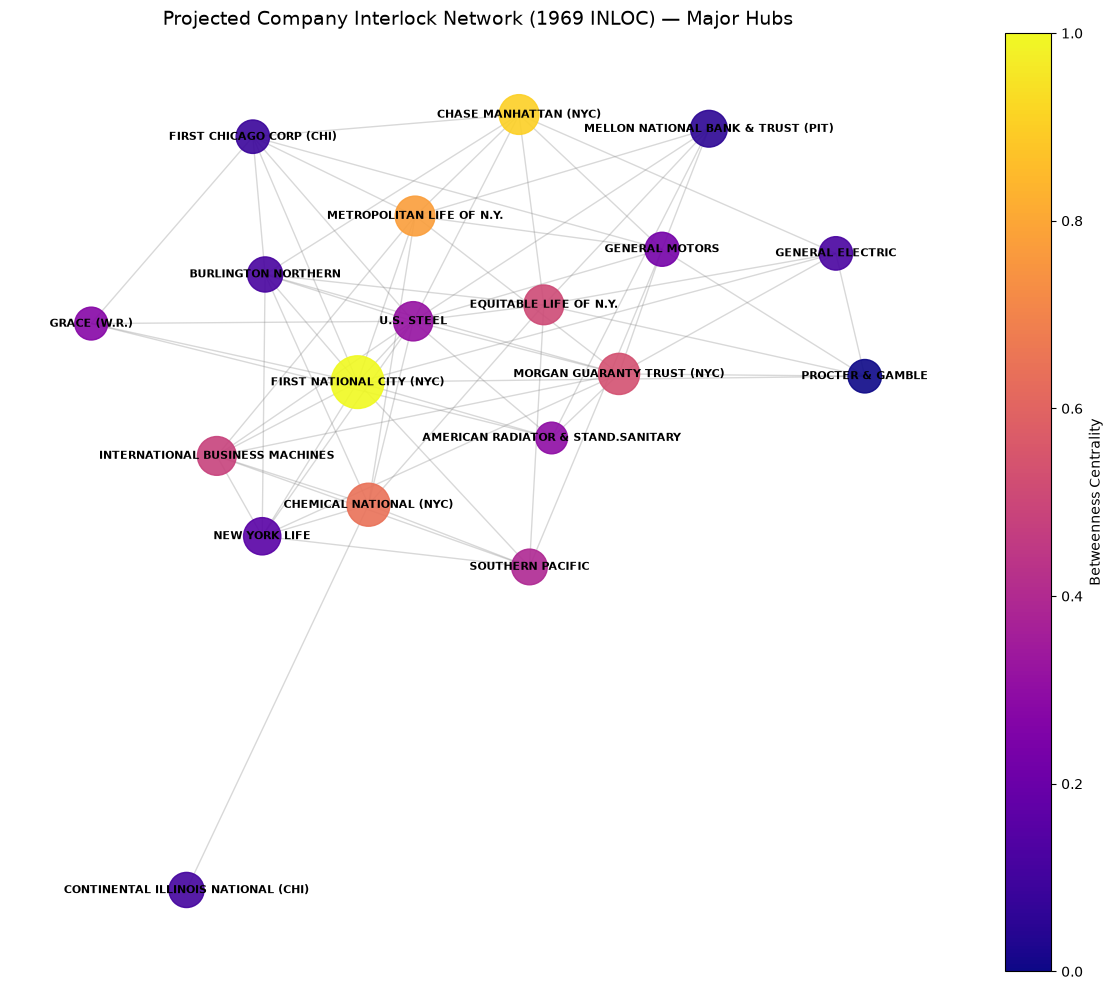

In [8]:
company_G = company_graph
# 4. Compute Centrality Measures
degree = dict(company_G.degree())
weighted_degree = dict(company_G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(company_G, weight="weight")
closeness = nx.closeness_centrality(company_G)
eigenvector = nx.eigenvector_centrality(company_G, weight="weight", max_iter=1000)

# Compile into a DataFrame
centrality_df = pd.DataFrame(
    {
        "Degree": degree,
        "Weighted_Degree": weighted_degree,
        "Betweenness": betweenness,
        "Closeness": closeness,
        "Eigenvector": eigenvector,
    }
).sort_values(by="Betweenness", ascending=False)

print(centrality_df.head(10))

# 5. Draw Subgraph of Core Hubs (Degree >= 10 for visual clarity)
sub_nodes = [n for n, d in company_G.degree() if d >= 15]
sub_G = company_G.subgraph(sub_nodes)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(sub_G, k=0.35, seed=42)

# Size nodes by Weighted Degree, Color by Betweenness Centrality
node_sizes = [weighted_degree[n] * 20 + 200 for n in sub_G.nodes()]
node_colors = [betweenness[n] for n in sub_G.nodes()]

nx.draw_networkx_nodes(
    sub_G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.9,
)
nx.draw_networkx_edges(sub_G, pos, alpha=0.3, edge_color="gray")
nx.draw_networkx_labels(
    sub_G, pos, font_size=8, font_weight="bold", font_color="black"
)

plt.title(
    "Projected Company Interlock Network (1969 INLOC) — Major Hubs", fontsize=14
)
plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.plasma),
    label="Betweenness Centrality",
    ax=plt.gca(),
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Display Top Interlocked Company Pairs
edges_sorted = sorted(
    company_G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True
)
print("\n--- Top Interlocked Company Pairs (Shared Directors) ---")
for u, v, d in edges_sorted[:5]:
    print(f"  {u} <---> {v}: {d['weight']} shared directors")


--- Top Interlocked Company Pairs (Shared Directors) ---
  SEABOARD AIR LINE <---> LOUISVILLE & NASHVILLE: 5 shared directors
  MELLON NATIONAL BANK & TRUST (PIT) <---> GULF OIL: 5 shared directors
  AVCO <---> REPUBLIC IRON & STEEL: 4 shared directors
  NATIONAL CASH REGISTER <---> FIRST NATIONAL CITY (NYC): 4 shared directors
  INTERNATIONAL HARVESTER <---> CONTINENTAL ILLINOIS NATIONAL (CHI): 4 shared directors


In [10]:

C_graph = company_G


# 5. Community Detection (Louvain Algorithm)
communities = nx.community.louvain_communities(
    C_graph, weight="weight", seed=42
)
print(f"\nDetected {len(communities)} corporate communities via Louvain.")




Detected 23 corporate communities via Louvain.


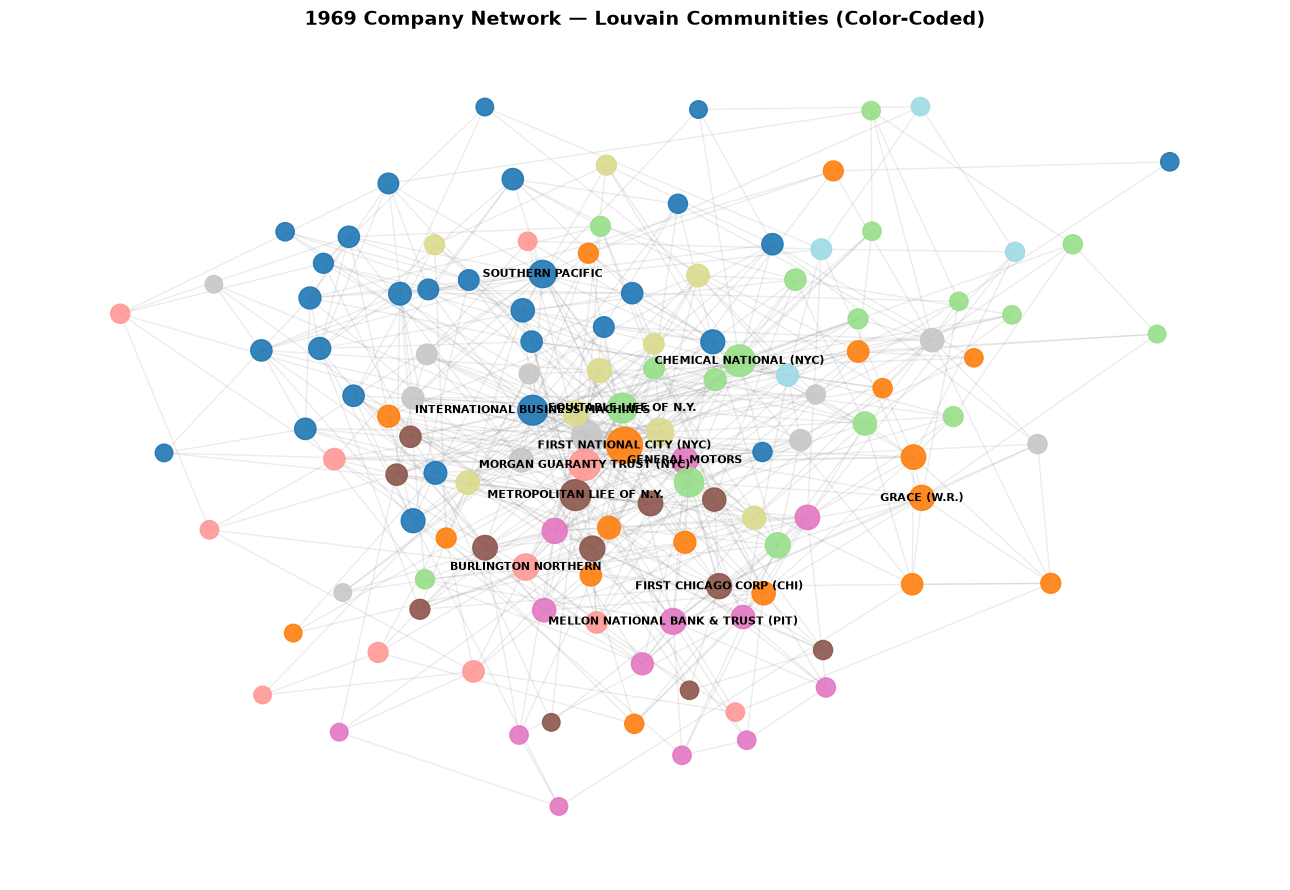

In [11]:
# Sort communities by size (number of member companies)
communities_sorted = sorted(communities, key=len, reverse=True)

# 4. Map each company to its assigned community ID for plot coloring
community_map = {}
for comm_id, comm in enumerate(communities_sorted):
    for company in comm:
        community_map[company] = comm_id

# 5. Plot Network Colored by Louvain Community
plt.figure(figsize=(13, 9))

# Filter for major nodes (degree >= 4) for visual clarity
sub_nodes = [n for n in company_G.nodes() if company_G.degree(n) >= 4]
subG = company_G.subgraph(sub_nodes)

pos = nx.spring_layout(subG, k=0.25, seed=42)

# Color nodes by community ID; size nodes by degree
colors = [community_map[n] for n in subG.nodes()]
sizes = [company_G.degree(n) * 15 + 100 for n in subG.nodes()]

nx.draw_networkx_edges(subG, pos, alpha=0.15, edge_color="gray")
nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=sizes,
    node_color=colors,
    cmap=plt.cm.tab20,
    alpha=0.9,
)

# Label top companies across major communities
top_labels = {}
for comm in communities_sorted[:6]:
    sorted_members = sorted(
        comm, key=lambda n: company_G.degree(n), reverse=True
    )
    for n in sorted_members[:2]:
        if n in subG:
            top_labels[n] = n

nx.draw_networkx_labels(
    subG, pos, labels=top_labels, font_size=8, font_weight="bold"
)

plt.title(
    "1969 Company Network — Louvain Communities (Color-Coded)",
    fontsize=14,
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# 4. Find the community containing Mellon Bank
target = "MELLON NATIONAL BANK & TRUST (PIT)"
mellon_comm = next(c for c in communities if target in c)

# 5. Extract and print the other companies in the community
other_companies = sorted([c for c in mellon_comm if c != target])

print(
    f"Found {len(other_companies)} other companies in Mellon Bank's community:\n"
)
for company in other_companies:
    print(f" - {company}")

Found 12 other companies in Mellon Bank's community:

 - ALUMINUM CO. OF AMERICA
 - ARMCO STEEL
 - CHICAGO, MILWAUKEE & ST.PAUL
 - EASTMAN KODAK (2)
 - GENERAL MOTORS
 - GOODYEAR TIRE & RUBBER
 - GULF OIL
 - MARATHON OIL
 - OWENS-ILLINOIS GLASS
 - PITTSBURGH PLATE GLASS
 - PROCTER & GAMBLE
 - TRW


In [13]:
target_company = "MELLON NATIONAL BANK & TRUST (PIT)"
mellon_comm = next(c for c in communities if target_company in c)

# 4. Extract Subgraph for Mellon Community Only
mellon_subG = company_G.subgraph(mellon_comm)

# 5. Create Labeled Pandas Adjacency Matrix
adj_df = nx.to_pandas_adjacency(mellon_subG, weight="weight", dtype=int)

# Sort rows and columns by total community connections for better readability
degree_order = sorted(
    mellon_comm,
    key=lambda n: mellon_subG.degree(n, weight="weight"),
    reverse=True,
)
adj_df = adj_df.loc[degree_order, degree_order]

print("--- Mellon Bank Community Adjacency Matrix ---")
adj_df


--- Mellon Bank Community Adjacency Matrix ---


,MELLON NATIONAL BANK & TRUST (PIT),PROCTER & GAMBLE,ARMCO STEEL,GOODYEAR TIRE & RUBBER,GULF OIL,ALUMINUM CO. OF AMERICA,TRW,GENERAL MOTORS,PITTSBURGH PLATE GLASS,MARATHON OIL,EASTMAN KODAK (2),OWENS-ILLINOIS GLASS,"CHICAGO, MILWAUKEE & ST.PAUL"
MELLON NATIONAL BANK & TRUST (PIT),0,0,1,1,5,3,1,1,3,0,0,0,0
PROCTER & GAMBLE,0,0,3,2,0,0,1,2,0,1,1,0,0
ARMCO STEEL,1,3,0,3,0,1,0,1,0,1,0,0,0
GOODYEAR TIRE & RUBBER,1,2,3,0,0,1,1,0,0,0,1,0,0
GULF OIL,5,0,0,0,0,2,0,0,2,0,0,0,0
ALUMINUM CO. OF AMERICA,3,0,1,1,2,0,0,1,0,0,0,0,0
TRW,1,1,0,1,0,0,0,0,0,0,2,0,0
GENERAL MOTORS,1,2,1,0,0,1,0,0,0,0,0,0,0
PITTSBURGH PLATE GLASS,3,0,0,0,2,0,0,0,0,0,0,0,0
MARATHON OIL,0,1,1,0,0,0,0,0,0,0,0,2,0


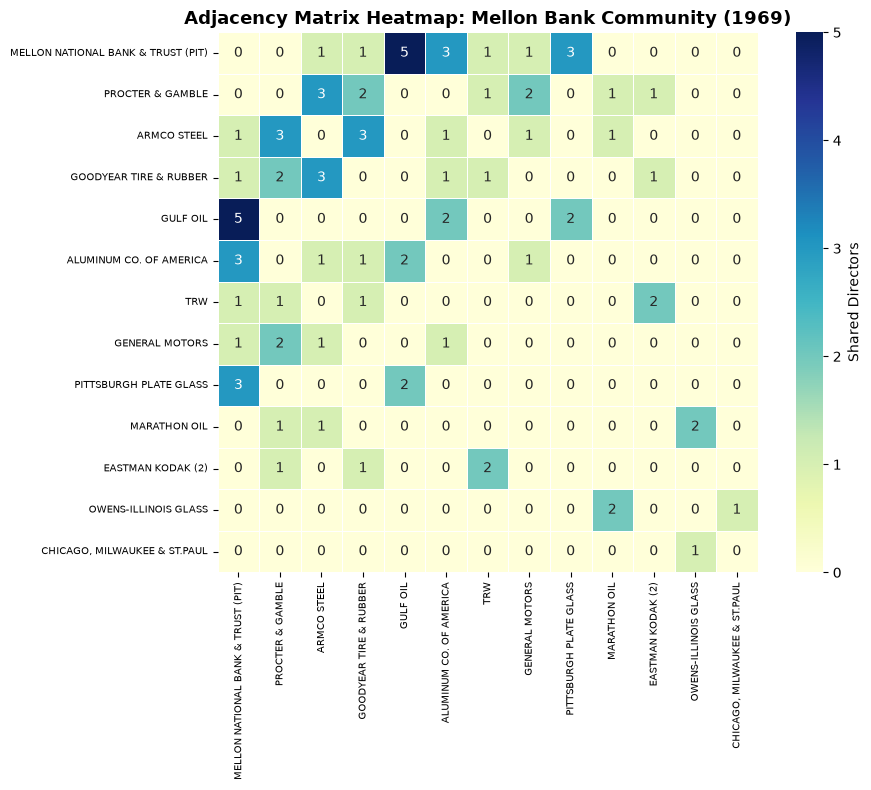

In [14]:

# 6. Plot Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    adj_df,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={"label": "Shared Directors"},
    linewidths=0.5,
    square=True,
)
plt.title(
    "Adjacency Matrix Heatmap: Mellon Bank Community (1969)",
    fontsize=13,
    fontweight="bold",
)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [15]:
# 3. Find Shortest Path between Deere & Co. and Boeing Airplane
source_company = "DEERE & CO."
target_company = "BOEING AIRPLANE"

try:
    # Get node sequence and path distance (number of hops)
    path = nx.shortest_path(
        company_G, source=source_company, target=target_company
    )
    hops = nx.shortest_path_length(
        company_G, source=source_company, target=target_company
    )

    print(f"Shortest Path Distance: {hops} hops\n")
    print("Company Path Sequence:")
    print(" -> ".join(path))

    # 4. Reveal the exact shared directors bridging each hop along the path
    print("\nDirector Interlocks Bridging Each Hop:")
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        directors_u = set(df_clean[df_clean["company"] == u]["person"])
        directors_v = set(df_clean[df_clean["company"] == v]["person"])
        shared = directors_u.intersection(directors_v)

        print(f"  [{i+1}] {u} <---> {v}")
        print(f"      Bridged by: {', '.join(shared)}\n")

except nx.NetworkXNoPath:
    print(f"No connected path exists between {source_company} and {target_company}.")

Shortest Path Distance: 3 hops

Company Path Sequence:
DEERE & CO. -> CONTINENTAL OIL -> MORGAN GUARANTY TRUST (NYC) -> BOEING AIRPLANE

Director Interlocks Bridging Each Hop:
  [1] DEERE & CO. <---> CONTINENTAL OIL
      Bridged by: HEWITT,W.A.

  [2] CONTINENTAL OIL <---> MORGAN GUARANTY TRUST (NYC)
      Bridged by: MC COLLUM,L.F., AUSTIN,J.P.

  [3] MORGAN GUARANTY TRUST (NYC) <---> BOEING AIRPLANE
      Bridged by: GREENEWALT,C.H.

